#### Практика 1. 

##### Сценарій

У продукті конверсія в оплату зазвичай ~10%. За два дні без змін:

* День 1: 10 000 користувачів → 1 050 оплат (10.5%)
* День 2: 10 000 користувачів → 980 оплат (9.8%)

##### Питання

1. Чи можна сказати, що «продукт погіршився» на День 2?
2. Які **реальні** причини, крім ефекту, можуть пояснити різницю?



### Практика 2
##### Сценарій

Є таблиця подій:

* `user_id, event_name, ts`
  Події: `view_page`, `start_trial`, `purchase`.

##### Питання

1. Як правильно визначити **конверсію в purchase** за день?
2. Яка типова помилка з подіями зламає метрику?


#### Практика 3. 

##### Сценарій

У тебе конверсія 10%.
Потрібно пояснити менеджеру, що означає «10%» для 20 користувачів.

##### Питання

Які значення оплат **можливі** і чому «рівно 2 оплати» — неправильна інтерпретація?



#### Практика 4.

##### Сценарій

Дві оцінки конверсії:

* Варіант A: 12 покупок із 100 (12%)
* Варіант B: 1 200 покупок із 10 000 (12%)

##### Питання

Чому другу оцінку вважаємо надійнішою?


#### Практика 5.

##### Сценарій

Метрики:

1. `purchase` (0/1)
2. `revenue` (грн)
3. `watch_time_sec` (сек)

##### Питання

1. Які типи випадкових величин?
2. Чому для `revenue` “середнє” часто бреше?


#### Практика 6.

##### Сценарій

Дві команди саппорту мають однаковий середній час відповіді: 60 секунд.

Команда A: 60,60,60,60,60
Команда B: 5,10,15,60,210

##### Питання

Яка команда краща для користувача і чому?



In [5]:
import numpy as np

A = [60,60,60,60,60]
B = [5,10,15,60,210]

print(np.std(A))
print(np.std(B))

0.0
77.52418977325722


In [ ]:
# MARK: // !!!! Need to insall scipy !!!!
# pip install scipy or conda install scipy 


0.0
77.52418977325722


In [6]:
stats.bernoulli.rvs?


Object `stats.bernoulli.rvs` not found.


In [14]:
import numpy as np
from scipy import stats

np.random.seed(1) # ядро генерації, значення будуть згенеровані лише один раз, а не кожного разу новий

p = 0.10        # ймовірність успіху (1)
n = 100        # кількість спостережень

# Generate Bernoulli distribution
purchases = stats.bernoulli.rvs(p, size=n)

purchases

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
n_users = 1000 # кількість користувачів (випробувань)
p = 0.10 # ймовірність покупки

# Generate number of purchases using Binomial distribution
# генерація випадкових значень з біноміального розподілу
purchases_count = stats.binom.rvs(n=n_users, p=p, size=10) # size=1 — одне спостереження (кількість покупок за день / експеримент)

purchases_count # Результат — одне число, скільки покупок сталося з 1000 користувачів (тобто к-ть успіхів)

array([ 81,  85, 103,  90, 100,  97, 114,  99,  85, 108])

In [20]:
stats.norm.rvs?

Signature: stats.norm.rvs(*args, **kwds)
Docstring:
Random variates of given type.

Parameters
----------
arg1, arg2, arg3,... : array_like
    The shape parameter(s) for the distribution (see docstring of the
    instance object for more information).
loc : array_like, optional
    Location parameter (default=0).
scale : array_like, optional
    Scale parameter (default=1).
size : int or tuple of ints, optional
    Defining number of random variates (default is 1).
random_state : {None, int, `numpy.random.Generator`,
                `numpy.random.RandomState`}, optional

    If `random_state` is None (or `np.random`), the
    `numpy.random.RandomState` singleton is used.
    If `random_state` is an int, a new ``RandomState`` instance is
    used, seeded with `random_state`.
    If `random_state` is already a ``Generator`` or ``RandomState``
    instance, that instance is used.

Returns
-------
rvs : ndarray or scalar
    Random variates of given `size`.
File:      /opt/anaconda3/lib/p

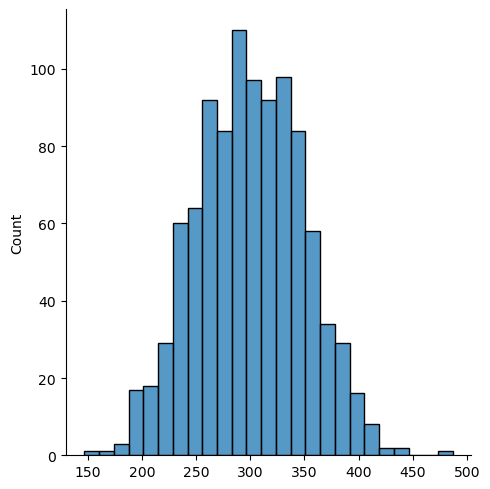

In [22]:
import seaborn as sns

# Параметри нормального розподілу
mean_check = 300   # середнє значення розподілу
std_check = 50     # стандартне відхилення
# n_samples = 1000   # кількість випадкових значень

# use stats.norm.rvs to generate normal dist. check function with ?
# Генерація випадкових значень з нормального розподілу
# stats.norm.rvs(loc=mean, scale=std, size=n_samples)
checks = stats.norm.rvs(loc=mean_check, scale=std_check, size=1000)

sns.displot(checks); 

In [ ]:
# use stats.binom.rvs with small n and p = 0.10 and size = 1000

b_s = stats.binom.rvs(n=10, p=0.10, size=1000)
print(b_s)

# use stats.binom.rvs with big n and p = 0.10 and size = 1000

b_b = stats.binom.rvs(n=100, p=0.10, size=1000)
print(b_b)

# збільшення вибірки - дає більш точний результат
# збільшення вибірки - менше шумів

[1 2 0 1 1 2 2 0 1 0 1 0 0 1 1 0 1 1 0 2 0 1 1 0 0 1 3 1 1 1 0 1 2 0 0 0 1
 3 0 1 0 3 0 1 2 1 1 0 1 0 0 1 0 0 1 3 1 0 0 3 0 0 1 1 1 0 0 3 0 1 1 1 0 0
 1 2 3 0 0 3 2 2 0 1 1 1 1 0 1 0 1 3 1 2 0 1 3 0 0 1 0 2 2 1 0 1 1 0 1 1 1
 0 1 0 0 2 2 0 0 0 0 0 0 1 1 1 1 0 3 2 2 2 3 1 0 1 2 2 1 0 1 2 1 1 0 1 2 1
 2 1 1 0 1 1 1 1 3 0 2 0 1 0 0 1 0 1 2 0 2 1 1 0 0 0 0 0 1 2 2 1 0 0 0 0 1
 1 1 1 2 2 0 2 3 0 1 1 3 2 0 1 1 1 0 2 1 2 2 2 1 1 0 1 0 1 0 0 0 0 1 1 1 0
 0 0 0 2 0 1 0 0 1 1 0 0 1 0 0 3 1 1 1 1 1 1 1 0 1 1 2 1 1 0 1 0 0 0 1 0 1
 2 0 1 1 0 2 0 1 1 1 1 0 0 1 1 2 2 2 1 0 2 1 0 2 2 1 0 1 2 2 0 0 2 1 1 3 0
 1 0 1 2 1 4 1 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 2 2 1 0 2 1 2 2 2 1 0 1 1 2 0
 0 2 2 2 2 1 1 2 1 1 0 1 1 0 0 0 0 0 1 2 1 0 0 1 1 2 1 2 0 1 0 3 1 0 0 0 1
 0 1 0 1 2 2 2 0 0 1 1 1 0 0 0 2 0 1 0 1 0 2 2 0 2 4 2 2 0 1 0 0 5 0 2 2 2
 4 0 0 1 0 0 1 2 1 0 1 0 0 2 1 2 0 2 1 1 1 2 1 1 4 2 1 1 1 0 1 2 2 0 1 0 4
 3 1 2 1 1 0 1 1 1 1 3 0 1 1 1 1 0 0 1 1 0 1 1 1 2 0 0 2 1 1 2 2 3 1 1 1 0
 1 0 2 1 1 1 0 0 1 0 1 2 

In [ ]:
import numpy as np
from scipy import stats

np.random.seed(2)

n = 500   # Кількість користувачів або спостережень
p = 0.10  # Ймовірність "успіху" 


# Генеруємо випадкові дані Бернуллі для групи A
A = stats.bernoulli.rvs(p, size=n)

# Генеруємо випадкові дані Бернуллі для групи B
B = stats.bernoulli.rvs(p, size=n)

# Проводимо двовибірковий t-тест (незалежні вибірки)
# ttest_ind повертає статистику t і p-value
p_value = stats.ttest_ind(B, A).pvalue

# Виводимо p-value, яке показує значимість різниці між групами
# якщо p-value <= 0.05 результат статистично значущий
print("p-value:", p_value)

p-value: 0.3047779346429746


In [ ]:
import numpy as np
from scipy import stats


np.random.seed(42)

n = 500 # Кількість спостережень (наприклад, користувачів)

# Ймовірності покупки для варіантів A і B
p_a = 0.10
p_b = 0.12

# use np.random.binomial to generate dist for p_a, p_b, with size n 
# Генеруємо біноміальні розподіли
# np.random.binomial(n=1, p=p, size=n) → 0 або 1 для кожного користувача
purchases_a = np.random.binomial(n=1, p=p_a, size=n)
purchases_b = np.random.binomial(n=1, p=p_b, size=n)

print(purchases_a)
print(purchases_b)

[0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0
 0 0 0 0 1 0 0 1 0 0 0 0 

In [27]:
# calculate mean, can use .mean()
print(purchases_a.mean())
print(purchases_b.mean())

0.11
0.11


In [ ]:
# create two variables and save result of stats.ttest_ind(<you group result B>, <you group result A>)
t_stat, p_value = stats.ttest_ind(purchases_a, purchases_b)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.0
p-value: 1.0
